In [1]:
import sys
sys.path.append("src_log")

In [2]:
import numpy as np
import torch

# Choose device
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float64

print("Using device:", device)

import grid_log
import importlib
import cosmology
import collision_log
#from kinematics import energy, cosphi, mandelstam_s_t, sqrt_one_minus_cosphi2

from cosmology import StdCosmology, build_T_of_a_table
#from grid_log import make_log_q_grid, interp_nearest_log_uniform_vec

#from grid import grid_edges_from_centers, bin_widths_from_centers, from grid import, interp_linear_uniform

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

Using device: cpu


In [3]:
from grid_log import make_log_q_grid as mygrid

qmin = 10**(-3)
qmax = 10**2
N = 100
a =1

q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)
p = q / a

In [4]:
cosmo = StdCosmology(gstar=106.75)
T_of_a, H_of_a, (amin, amax) = build_T_of_a_table(cosmo, Trh=150.0, ai=1.0)

print(amin, amax)
print(T_of_a(1.0), H_of_a(1.0))

0.9999999999999998 1500000.0
150.0 3.16152130195488e-14


In [5]:
T_of_a(10.)

array(15.00000087)

In [6]:
H_of_a(10.)

3.1615216686597294e-16

# Checking the kernel of the collision operator F

In [7]:
from functools import partial
import solver
import func

from func import gamma_ap_to_ff,  gamma_ap_total_to_sm_fermions
from solver import integrate_rk4_a, integrate_rk4_a_trajectory

# Computing $C_\text{IF}$ as a check

# We try to solve the equation just with FI dynamics

In [8]:
alpha = 1/137

# Rough width: Gamma ~ alpha * eps^2 * m
lam = 0.05
g = 0.01
v = 1
mA = g*v
mh = np.sqrt(lam/3)*v

eps = 6e-10
m_med = mA
Gamma = alpha * eps**2 * m_med

Gamma = gamma_ap_total_to_sm_fermions(
    mA, eps,
    alpha_em=1/137.035999084,
    include=("e","mu","tau","u","d","s","c","b","t"),
)

gchi = 1.
#lam = 0*1e-3
#m_med = 0.018
#m_med = mA


In [9]:
mh

0.12909944487358055

In [10]:
mA

0.01

In [11]:
Gamma

2.1766839253524552e-23

In [12]:
# Choose grid and params (keep modest while testing)
from collision_log import rhs_dfFI_da_torch

N = 90
qmin = 10**(-3)
qmax = 10**3
#a =1

batch_size = 32

q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)
#p = q / a


In [13]:
a0 = 1.0
a1 = 5.
n_steps = 100


rhsFI = partial(
    rhs_dfFI_da_torch,
    q=q, dq=dlogq, m=mA, lam=lam,
    H_of_a=H_of_a, T_of_a=T_of_a,
    m_med=mA, Gamma=Gamma, pref_FI=1.0,
    gchi=gchi, batch_size=batch_size
)

f0 = torch.zeros_like(q)   # (N,)
f1 = integrate_rk4_a(f0, a0, a1, n_steps, rhsFI)

print("f0:", f0.shape, f0.dtype, f0.device)
print("f1:", f1.shape, f1.dtype, f1.device)
print("finite:", torch.isfinite(f1).all().item())


f0: torch.Size([90]) torch.float64 cpu
f1: torch.Size([90]) torch.float64 cpu
finite: True


In [14]:
Gamma

2.1766839253524552e-23

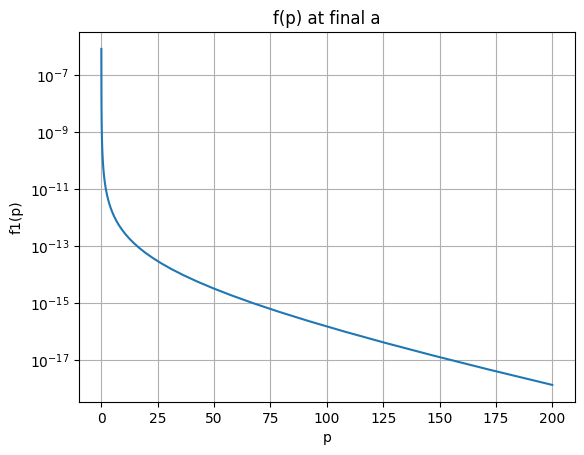

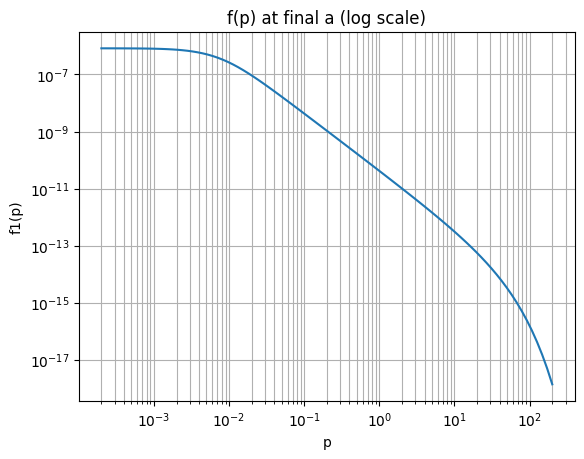

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import func
from func import f_FI_inverse_decay_MB_analytic_p



q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)

a_1 = torch.tensor(a1, device=device, dtype=dtype)



# Physical p, E
p = q/a1

p_cpu  = p.detach().cpu().numpy()
f1_cpu = f1.detach().cpu().numpy()

plt.figure()
plt.plot(p_cpu, f1_cpu)
plt.xlabel("p")
#plt.xscale("log")
plt.ylabel("f1(p)")
plt.yscale("log")
plt.title("f(p) at final a")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(p_cpu, np.maximum(f1_cpu, 1e-300))
plt.xlabel("p")
plt.xscale("log")

plt.ylabel("f1(p)")
plt.title("f(p) at final a (log scale)")
plt.grid(True, which="both")
plt.show()


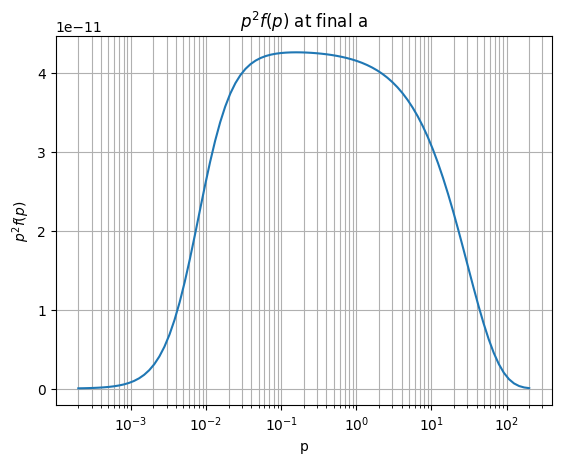

In [16]:
#Gamma = 1e-20 # GeV (example)
fan = f_FI_inverse_decay_MB_analytic_p(p_cpu, a1, mA, Gamma)


plt.figure()
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(f1_cpu, 1e-300))
#plt.semilogy(p_cpu, p_cpu**2 * np.maximum(fan, 1e-300))

#plt.ylim(10**(-9),1.5*10**(-6))   # set y-axis range
#plt.xlim(10**(-3),10**(1))   # set y-axis range

plt.xlabel("p")
plt.xscale("log")


plt.ylabel(r"$p^2 f(p)$")
plt.yscale("linear")


plt.title(r"$p^2 f(p)$ at final a")
plt.grid(True, which="both")
#plt.show()


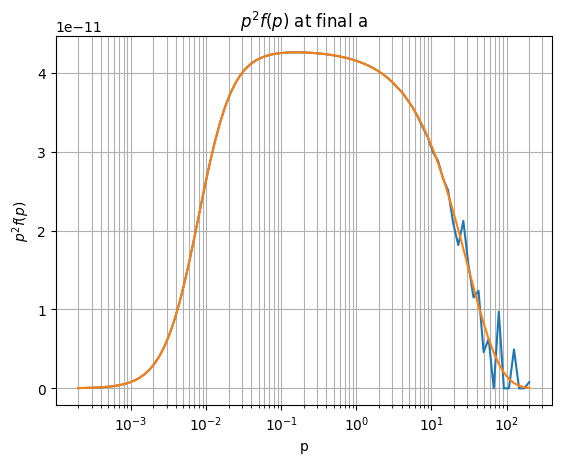

In [17]:
#Gamma = 1e-20 # GeV (example)
fan = f_FI_inverse_decay_MB_analytic_p(p_cpu, a1, mA, Gamma)


plt.figure()
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(fan, 1e-300))
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(f1_cpu, 1e-300))

#plt.ylim(10**(-9),1.5*10**(-6))   # set y-axis range
#plt.xlim(10**(-3),10**(1))   # set y-axis range

plt.xlabel("p")
plt.xscale("log")


plt.ylabel(r"$p^2 f(p)$")
plt.yscale("linear")


plt.title(r"$p^2 f(p)$ at final a")
plt.grid(True, which="both")
#plt.show()


# Now with everything included 

In [16]:
alpha = 1/137


# Rough width: Gamma ~ alpha * eps^2 * m
#mA=0.3
#m_t = 0.018


m_med = mA
eps = 6e-10
Gamma = alpha * eps**2 * m_med

Gamma = gamma_ap_total_to_sm_fermions(
    mA, eps,
    alpha_em=1/137.035999084,
    include=("e","mu","tau","u","d","s","c","b","t"),
)

gchi = 1.
lam = 1e-3

#m_med = 0.018
#m_med = mA

In [25]:
Gamma

2.1766839253524552e-23

In [26]:
mA

0.01

In [27]:
mh

0.12909944487358055

In [18]:
# Choose grid and params (keep modest while testing)
from collision_log import rhs_df_da_torch_logq


N = 90
qmin = 10**(-3)
qmax = 10**3
#a0 = 1
#a1 = 5.


batch_size = 32

q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)
p = q / a

f0 = torch.zeros_like(q)   # (N,)

rhs = partial(
    rhs_df_da_torch_logq,
    q=q,
    logq0=logq0,
    dlogq=dlogq,
    log_space=log_space,
    m=mh,
    lam=lam,
    H_of_a=H_of_a,
    T_of_a=T_of_a,
    m_med=mA,
    Gamma=Gamma,
    pref_FI=1.0,
    gchi=gchi,
    batch_size=batch_size
)

# now rhs has signature rhs(f,a)
fall = integrate_rk4_a(f0, a0, a1, n_steps, rhs)


weighted outside (loss) fraction: 0.0
weighted outside (loss) fraction: 0.0
weighted outside (loss) fraction: 0.0
weighted outside (loss) fraction: 6.158688802840537e-12
weighted outside (loss) fraction: 7.387198189840842e-11
weighted outside (loss) fraction: 2.1038174635234719e-10
weighted outside (loss) fraction: 6.351087645047682e-12
weighted outside (loss) fraction: 7.518266082781761e-11
weighted outside (loss) fraction: 2.188315045338755e-10
weighted outside (loss) fraction: 6.351114244371538e-12
weighted outside (loss) fraction: 7.523063814318973e-11
weighted outside (loss) fraction: 2.1883371362013219e-10
weighted outside (loss) fraction: 6.353297488067107e-12
weighted outside (loss) fraction: 7.52497613662951e-11
weighted outside (loss) fraction: 2.1891791287469913e-10
weighted outside (loss) fraction: 6.418727184372283e-12
weighted outside (loss) fraction: 7.577678827466384e-11
weighted outside (loss) fraction: 2.2179952893897662e-10
weighted outside (loss) fraction: 6.4879519

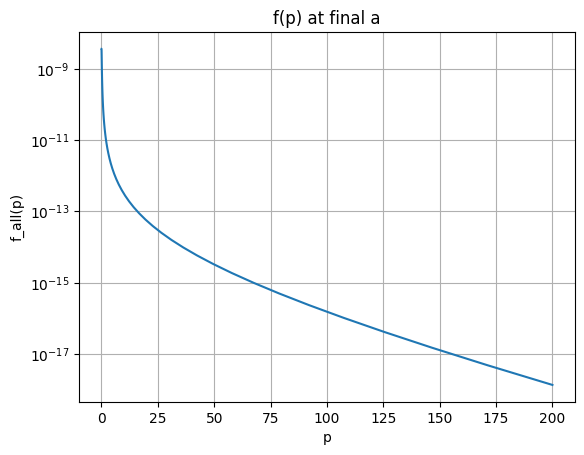

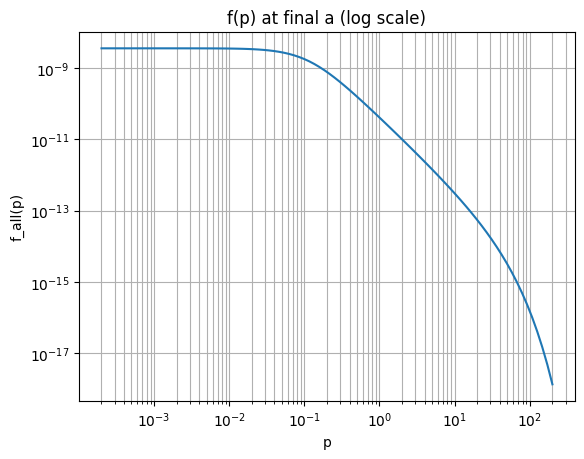

In [25]:
q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)

a_1 = torch.tensor(a1, device=device, dtype=dtype)



# Physical p, E
p = q/a1

p_cpu  = p.detach().cpu().numpy()
fall_cpu = fall.detach().cpu().numpy()

plt.figure()
plt.plot(p_cpu, fall_cpu)
plt.xlabel("p")
#plt.xscale("log")
plt.ylabel("f_all(p)")
plt.yscale("log")
plt.title("f(p) at final a")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(p_cpu, np.maximum(fall_cpu, 1e-300))
plt.xlabel("p")
plt.xscale("log")

plt.ylabel("f_all(p)")
plt.title("f(p) at final a (log scale)")
plt.grid(True, which="both")
plt.show()

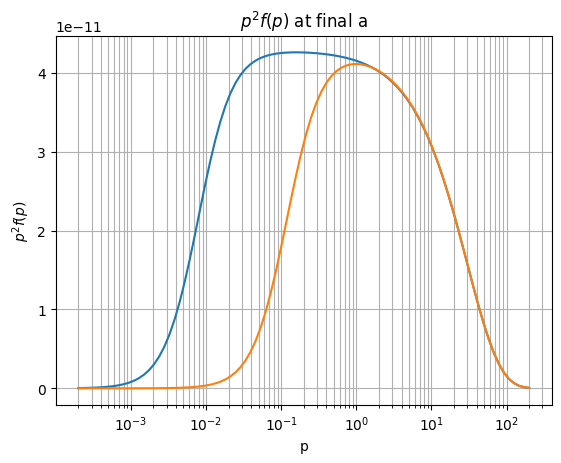

In [26]:
plt.figure()
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(f1_cpu, 1e-300))
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(fall_cpu, 1e-300))
#plt.semilogy(p_cpu, p_cpu**2 * np.maximum(fan, 1e-300))

#plt.ylim(10**(-9),1.5*10**(-6))   # set y-axis range
#plt.xlim(10**(-3),10**(1))   # set y-axis range

plt.xlabel("p")
plt.xscale("log")


plt.ylabel(r"$p^2 f(p)$")
plt.yscale("linear")


plt.title(r"$p^2 f(p)$ at final a")
plt.grid(True, which="both")
#plt.show()


In [21]:
fall

tensor([3.5870e-09, 3.5870e-09, 3.5870e-09, 3.5870e-09, 3.5870e-09, 3.5869e-09,
        3.5869e-09, 3.5869e-09, 3.5868e-09, 3.5867e-09, 3.5866e-09, 3.5864e-09,
        3.5862e-09, 3.5859e-09, 3.5854e-09, 3.5849e-09, 3.5841e-09, 3.5830e-09,
        3.5815e-09, 3.5795e-09, 3.5768e-09, 3.5731e-09, 3.5680e-09, 3.5612e-09,
        3.5520e-09, 3.5395e-09, 3.5229e-09, 3.5007e-09, 3.4713e-09, 3.4328e-09,
        3.3830e-09, 3.3192e-09, 3.2388e-09, 3.1390e-09, 3.0172e-09, 2.8713e-09,
        2.7002e-09, 2.5042e-09, 2.2855e-09, 2.0487e-09, 1.8005e-09, 1.5497e-09,
        1.3057e-09, 1.0772e-09, 8.7117e-10, 6.9187e-10, 5.4074e-10, 4.1686e-10,
        3.1769e-10, 2.3984e-10, 1.7969e-10, 1.3380e-10, 9.9145e-11, 7.3174e-11,
        5.3830e-11, 3.9490e-11, 2.8902e-11, 2.1108e-11, 1.5386e-11, 1.1192e-11,
        8.1254e-12, 5.8862e-12, 4.2542e-12, 3.0667e-12, 2.2040e-12, 1.5787e-12,
        1.1263e-12, 7.9992e-13, 5.6511e-13, 3.9676e-13, 2.7657e-13, 1.9117e-13,
        1.3085e-13, 8.8538e-14, 5.9111e-

In [22]:
import collision_log
from collision_log import C_self_with_F_torch_batched_logq #, enforce_number_energy

Ng = 128          # angular quadrature order
batch_size = 32

#q, dq = make_uniform_q_grid(qmin, qmax, N, device=device, dtype=dtype)

#a_t = torch.tensor(a, device=device, dtype=dtype)
#m_t = torch.tensor(m, device=device, dtype=dtype)



#Tt = torch.tensor(Tchi, device=device, dtype=dtype)
#f = f_MB_torch(E, Tt, A=1.0)
#f = torch.ones_like(p)      # safest: matches shape, dtype, device


#C , E_out, p_out, dp = C_self_with_F_torch_batched_snapped(
#    f, a_t, q, dq, m_t,
#    lam=lam, gchi=1.0,
#    Ng=Ng, batch_size=batch_size,
#    snap_mode="nearest",          # "nearest" or "floor"
#    return_debug=False
#)

C, E_out, p_out, dp = C_self_with_F_torch_batched_logq(
    fall, a1,
    q, logq0, dlogq, log_space,
    m_med, lam=lam, gchi=1.0,
    Ng=32, batch_size=16
)

#C, E_out, p_out, dp = C_self_plumbing_torch_batched(f, a_t, q, dq, m_t, gchi=1.0, batch_size=16)

weighted outside (loss) fraction: 4.781191519240451e-11
weighted outside (loss) fraction: 9.812043400540505e-11
weighted outside (loss) fraction: 3.5989217128364714e-10
weighted outside (loss) fraction: 2.3859028252647245e-09
weighted outside (loss) fraction: 3.636014625115199e-09
weighted outside (loss) fraction: 1.469778182967161e-09


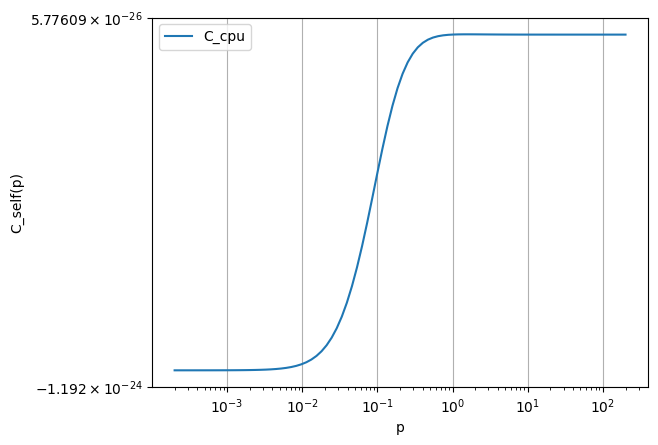

max|C| = 1.135196490534891e-24


In [23]:
#C2 = enforce_number_energy(C, p, E, dp, eps=0.0)

# Plot
p_cpu = p_out.detach().cpu().numpy()
C_cpu = C.detach().cpu().numpy()

# Plot
#C_cpu2 = C2.detach().cpu().numpy()

plt.figure()

plt.plot(p_cpu, C_cpu, label="C_cpu")
#plt.plot(p_cpu, C_cpu2, label="C_cpu2")

plt.yscale("symlog")
plt.xlabel("p")
plt.xscale("log")


plt.ylabel("C_self(p)")
#plt.title("Collision term for MB input (should be ~0)")
plt.grid(True)
plt.legend()

plt.show()


print("max|C| =", float(torch.max(torch.abs(C))))


# Now with the collision operator having elastic scattering $AA\to AA$

In [33]:
alpha = 1/137


# Rough width: Gamma ~ alpha * eps^2 * m
lam = 0.001
g = 0.08
v = 1
mA = g*v
mh = np.sqrt(lam/3)*v

eps = 6e-10
Gamma = alpha * eps**2 * mA

Gamma = gamma_ap_total_to_sm_fermions(
    mA, eps,
    alpha_em=1/137.035999084,
    include=("e","mu","tau","u","d","s","c","b","t"),
)

gchi = 1.
lam = 1e-3

#m_med = 0.018
#m_med = mA

In [34]:
# Choose grid and params (keep modest while testing)
from collision_log import rhs_df_da_torch_logq_t,rhs_dfFI_da_torch
from functools import partial

N = 50
qmin = 10**(-3)
qmax = 10**2
a0 = 1
a1 = 4.

batch_size = 32

n_steps = 40
Ng=32

q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)

f0 = torch.zeros_like(q)   # (N,)

rhsFI = partial(
    rhs_dfFI_da_torch,
    q=q, dq=dlogq, m=mA, lam=lam,
    H_of_a=H_of_a, T_of_a=T_of_a,
    m_med=mA, Gamma=Gamma, pref_FI=1.0,
    gchi=gchi, batch_size=batch_size
)

f1 = integrate_rk4_a(f0, a0, a1, n_steps, rhsFI)

rhs_t = partial(
    rhs_df_da_torch_logq_t,
    q=q,
    logq0=logq0,
    dlogq=dlogq,
    log_space=log_space,
    mA=mA,
    mh=mh,
    g=g,
    H_of_a=H_of_a,
    T_of_a=T_of_a,
    m_med=mA,
    Gamma=Gamma,
    pref_FI=1.0,
    gchi=gchi,
    batch_size=batch_size,
)

a_hist, f_hist = integrate_rk4_a_trajectory(
    f0=f0, a0=a0, a1=a1, n_steps=n_steps, rhs=rhs_t,
    store_every=1,
    print_every_pct=10,
    out_path_pt="traj.pt",
    out_path_dat="traj.dat",   # readable in TextEdit/Mathematica
    atomic=True,
)

10% done!
20% done!
30% done!
40% done!
50% done!
60% done!
70% done!
80% done!
90% done!
100% done!


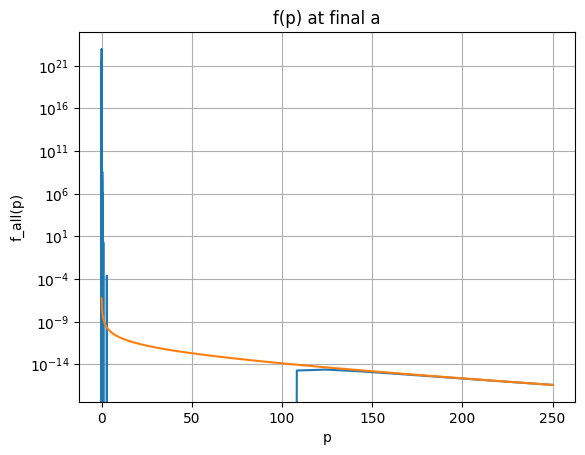

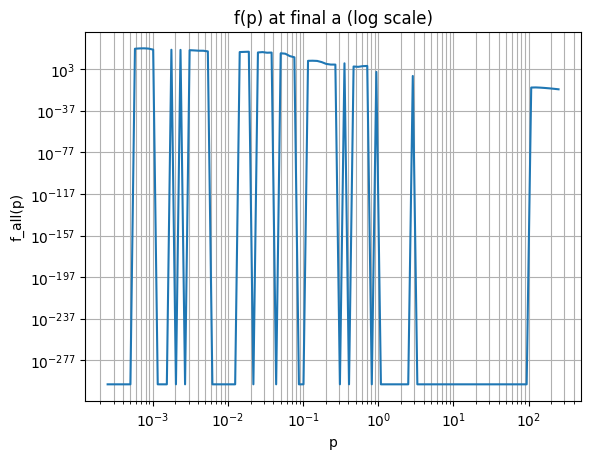

In [35]:
# Physical p, E
p = q/a1

p_cpu  = p.detach().cpu().numpy()
fall_cpu = f_hist[-1].detach().cpu().numpy()
f1_cpu = f1.detach().cpu().numpy()

plt.figure()
plt.plot(p_cpu, fall_cpu)
plt.plot(p_cpu, f1_cpu)

plt.xlabel("p")
#plt.xscale("log")
plt.ylabel("f_all(p)")
plt.yscale("log")
plt.title("f(p) at final a")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(p_cpu, np.maximum(fall_cpu, 1e-300))
plt.xlabel("p")
plt.xscale("log")

plt.ylabel("f_all(p)")
plt.title("f(p) at final a (log scale)")
plt.grid(True, which="both")
plt.show()

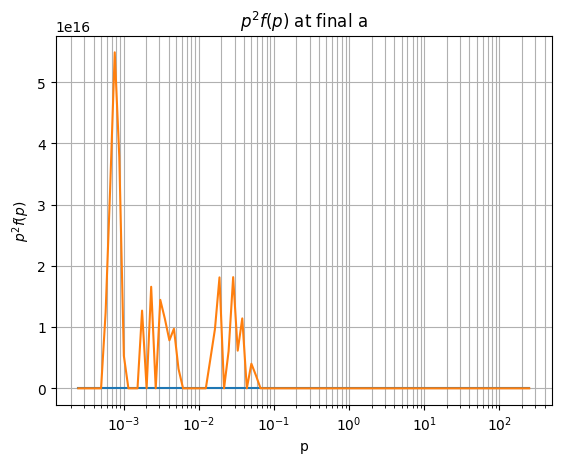

In [36]:
plt.figure()
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(f1_cpu, 1e-300))
plt.semilogy(p_cpu, p_cpu**2 * np.maximum(fall_cpu, 1e-300))
#plt.semilogy(p_cpu, p_cpu**2 * np.maximum(fan, 1e-300))

#plt.ylim(10**(-9),1.5*10**(-6))   # set y-axis range
#plt.xlim(10**(-3),10**(1))   # set y-axis range

plt.xlabel("p")
plt.xscale("log")


plt.ylabel(r"$p^2 f(p)$")
plt.yscale("linear")


plt.title(r"$p^2 f(p)$ at final a")
plt.grid(True, which="both")
#plt.show()